In [1]:
%reload_ext autoreload
%autoreload 2

# NanoBEIR

In [ ]:
from sentence_transformers import SentenceTransformer
from sentence_transformers.evaluation import NanoBEIREvaluator, InformationRetrievalEvaluator

models = {
    "ModernBERT_ST_original": "nomic-ai/modernbert-embed-base",
    "Indus_ST_original": "nasa-impact/nasa-smd-ibm-st-v2",
    "Indus_SDE_ST_intermediate_checkpoint_166k": "/rhome/sawale/indus_traning/sentense_transformers/model_exploration/tmp_models/nrows_None__nsrc_None/timestamp_20250505_16-10-36/_backup_checkpoint-167000"
}

datasets = ["QuoraRetrieval", "MSMARCO"]

ks = [1, 3, 5, 10]

evaluator = NanoBEIREvaluator(
    dataset_names=datasets,
    mrr_at_k = ks,
    accuracy_at_k = ks,
    precision_recall_at_k = ks,
    map_at_k = ks,
    ndcg_at_k = ks,
    show_progress_bar=True,
    batch_size = 32,
    write_csv = True
)


all_results = {}

for model_name, model_path in models.items():
    print(f"Evaluating model: {model_name}")
    model = SentenceTransformer(model_path)
    results = evaluator(model)

    # lets parse
    for k, v in results.items():
        k_parsed = k.split("_")
        full_metric_name = k_parsed[-2] + "_" + k_parsed[-1]
        dataset_name = "_".join(k_parsed[:-2])

    all_results[model_name] = results



Evaluating datasets:   0%|          | 0/2 [00:00<?, ?it/s]              

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Batches:   0%|          | 0/158 [00:00<?, ?it/s]

Evaluating datasets:  50%|█████     | 1/2 [00:17<00:17, 17.45s/it]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Batches:   0%|          | 0/158 [00:00<?, ?it/s]

Evaluating datasets: 100%|██████████| 2/2 [01:36<00:00, 48.48s/it]


NanoBEIR_mean_cosine_ndcg@10
0.7755549493198495


# NASA IR

In [17]:

from datasets import load_dataset
from sentence_transformers.evaluation import InformationRetrievalEvaluator
from sentence_transformers import SentenceTransformer

import json

ks = [1, 3, 5, 10]

models = {
    "modernbert-embed-base": "nomic-ai/modernbert-embed-base",
    "nasa-smd-ibm-st-v2": "nasa-impact/nasa-smd-ibm-st-v2",
    "indus-sde-st-v0.1": "nasa-impact/indus-sde-st-v0.1"
}

corpus = load_dataset("nasa-impact/nasa-smd-IR-benchmark", data_files="https://huggingface.co/datasets/nasa-impact/nasa-smd-IR-benchmark/resolve/main/corpus.jsonl", split="train")
queries = load_dataset("nasa-impact/nasa-smd-IR-benchmark", data_files="https://huggingface.co/datasets/nasa-impact/nasa-smd-IR-benchmark/resolve/main/queries.jsonl", split="train")
relevant_docs_data = load_dataset("nasa-impact/nasa-smd-IR-benchmark", split="test")


corpus = { row["_id"]: row["text"] for row in corpus }
queries = { row["_id"]: row["text"] for row in queries }
relevant_docs_data = relevant_docs_data.to_pandas().groupby("query-id")['corpus-id'].apply(set).to_dict()


evaluator = InformationRetrievalEvaluator(
                queries=queries,
                corpus=corpus,
                relevant_docs=relevant_docs_data,
                name="nasa_ir_evaluator",
                batch_size=8,
                mrr_at_k=ks,
                ndcg_at_k=ks,
                accuracy_at_k=ks,
                precision_recall_at_k=ks,
                map_at_k=ks,
                show_progress_bar=True,
                write_csv=True,
            )

all_results = {}

for model_name, model_path in models.items():
    print(f"Evaluating model: {model_name}")
    model = SentenceTransformer(model_path)
    results = evaluator(model)
    all_results[model_name] = results


with open("nasa_ir_eval_dump.json", "w", encoding="utf-8") as f:
    json.dump(all_results, f, ensure_ascii=False, indent=4)



Evaluating model: modernbert-embed-base


Batches: 0it [00:00, ?it/s]

Corpus Chunks:   0%|          | 0/6 [00:00<?, ?it/s]

Batches:   0%|          | 0/6250 [00:00<?, ?it/s]

Corpus Chunks:   0%|          | 0/6 [00:21<?, ?it/s]


KeyboardInterrupt: 

# plots for nanoBEIR

In [1]:
import json

# read nano_beir_eval_dump.json as dict

with open("nano_beir_eval_dump_v2.json", "r") as f:
    data_dump = json.load(f)

len(data_dump["ModernBERT_ST_original"]) / (4*6)


14.0

In [6]:


rename_keys = {'ModernBERT_ST_original': "modernbert-embed-base", 
               'Indus_ST_original': "nasa-smd-ibm-st-v2", 
               'Indus_SDE_ST_STAGE1': "indus-sde-st-v0.1"}
data_dump = {rename_keys.get(k):v for k,v in data_dump.items()}

data_dump.keys()

dict_keys(['modernbert-embed-base', 'nasa-smd-ibm-st-v2', 'indus-sde-st-v0.1'])

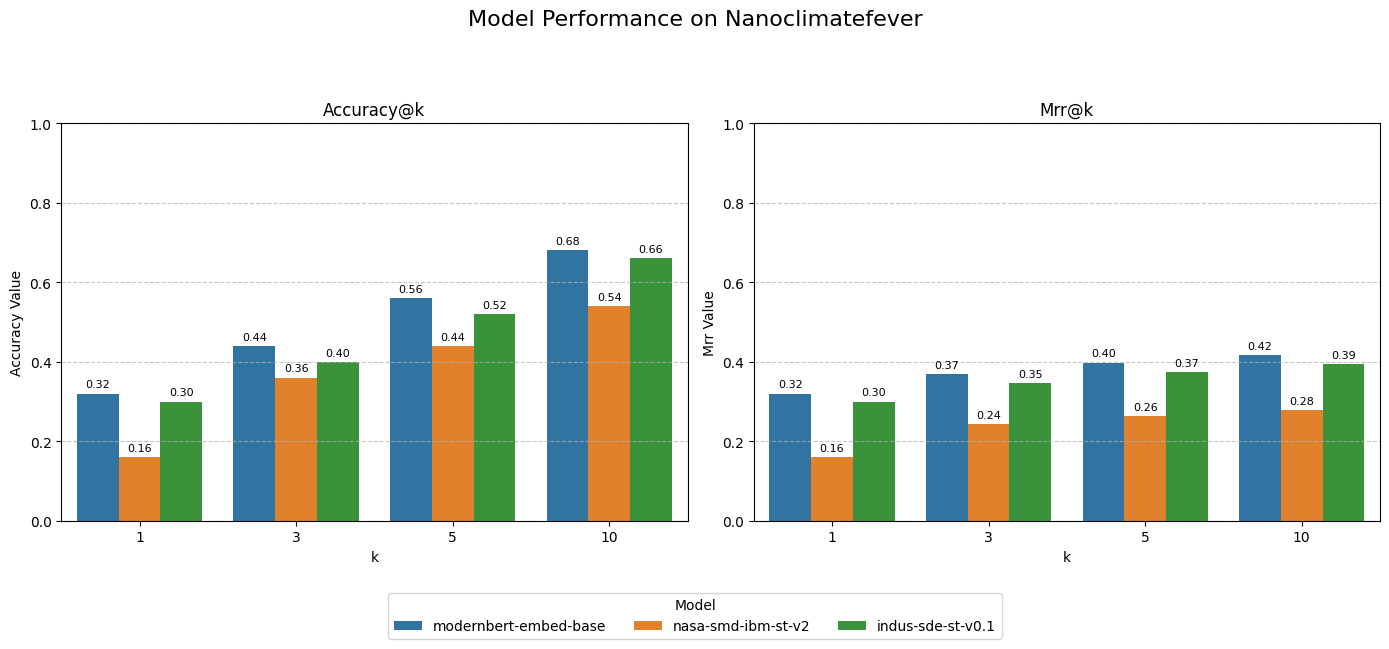

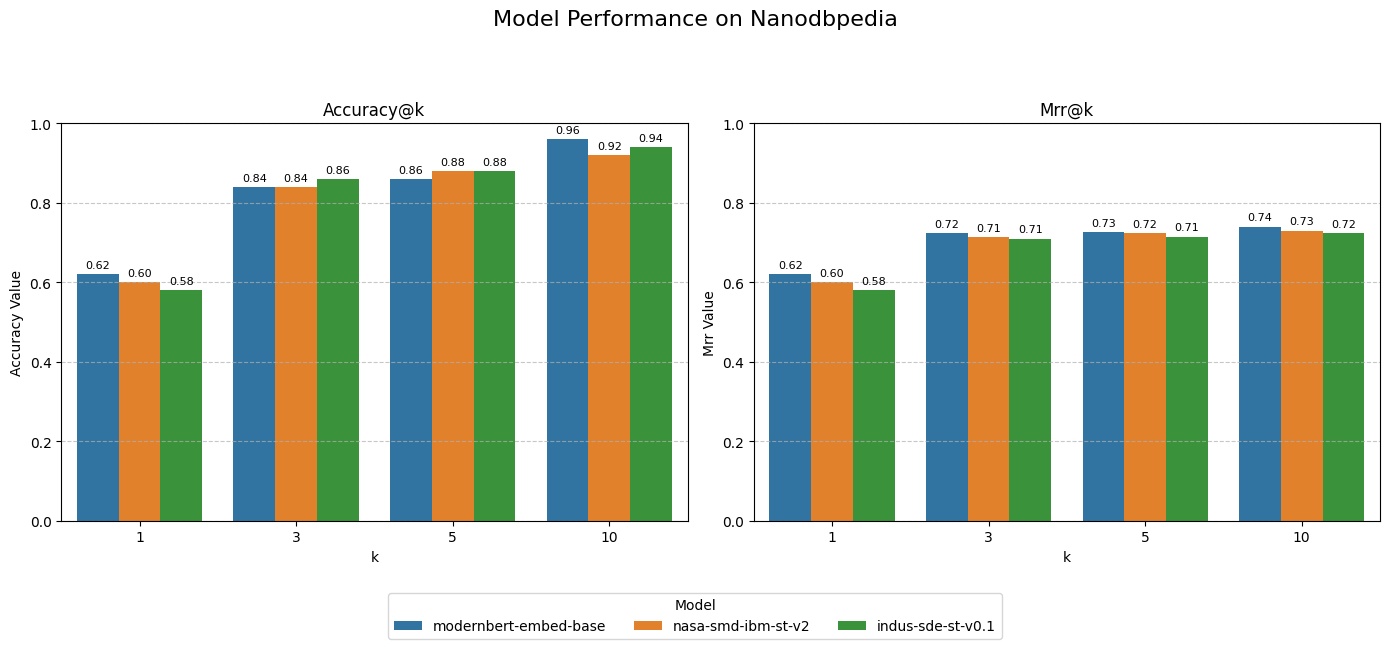

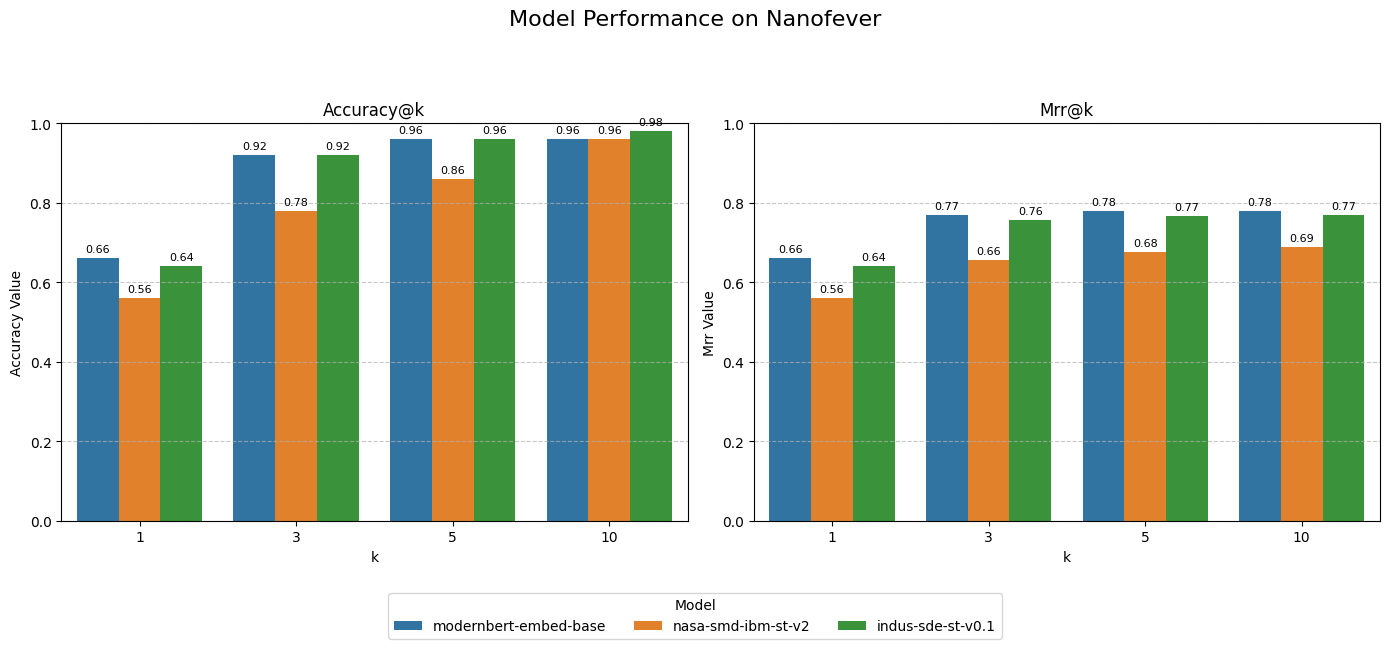

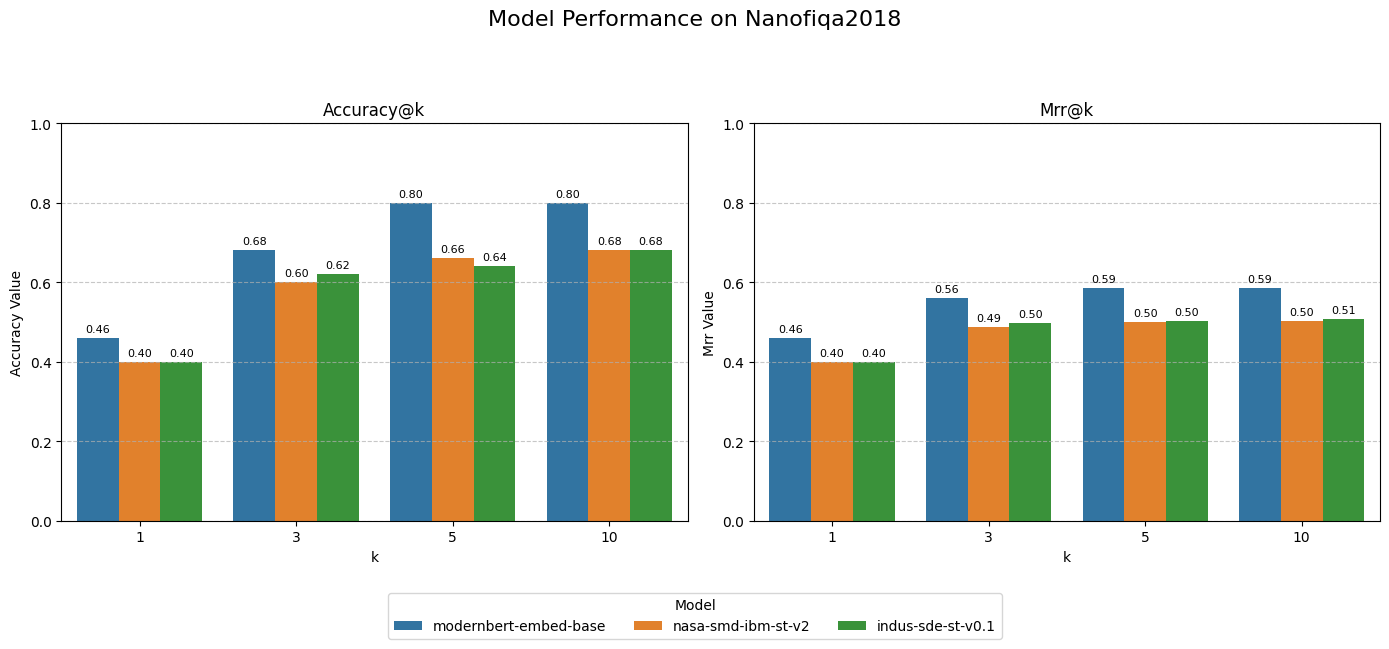

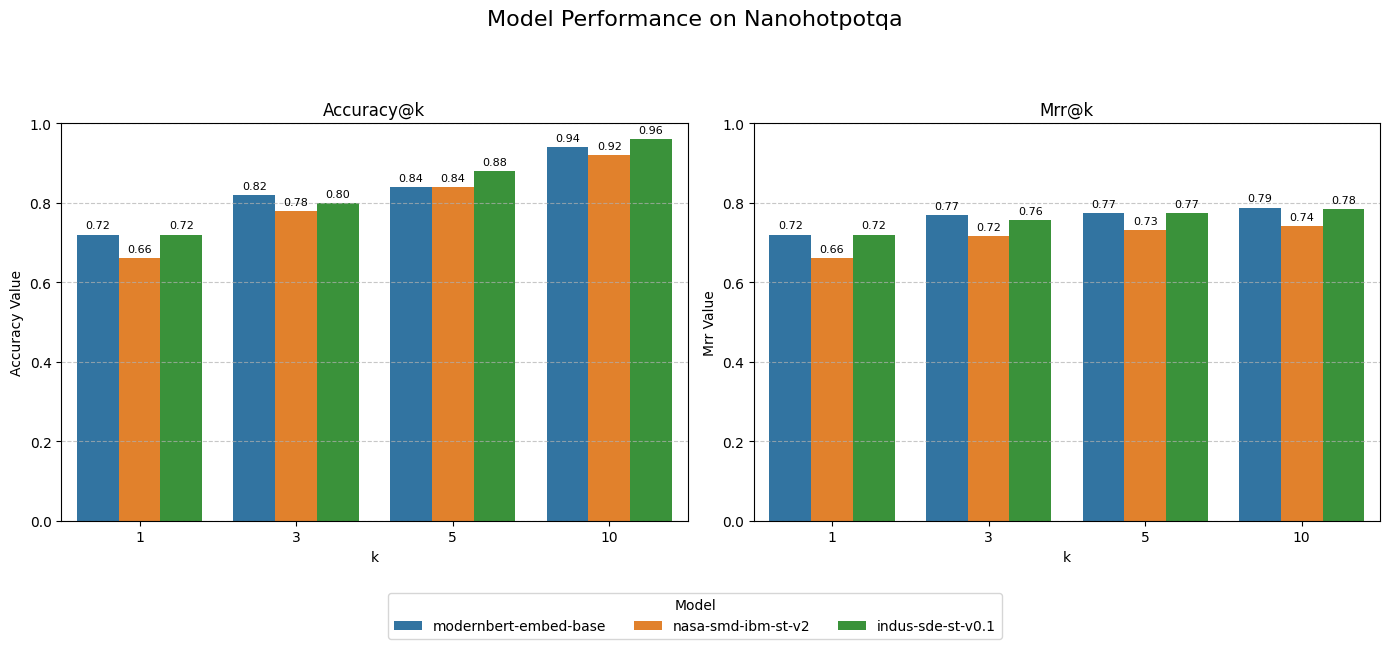

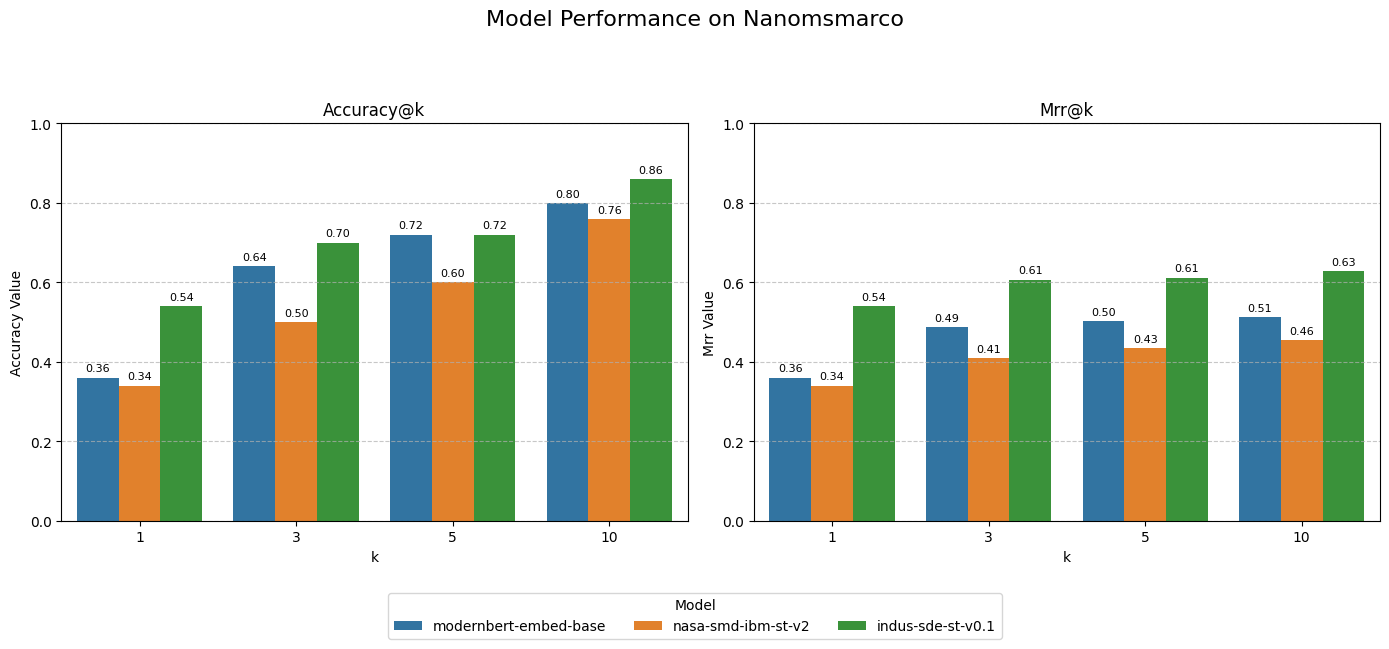

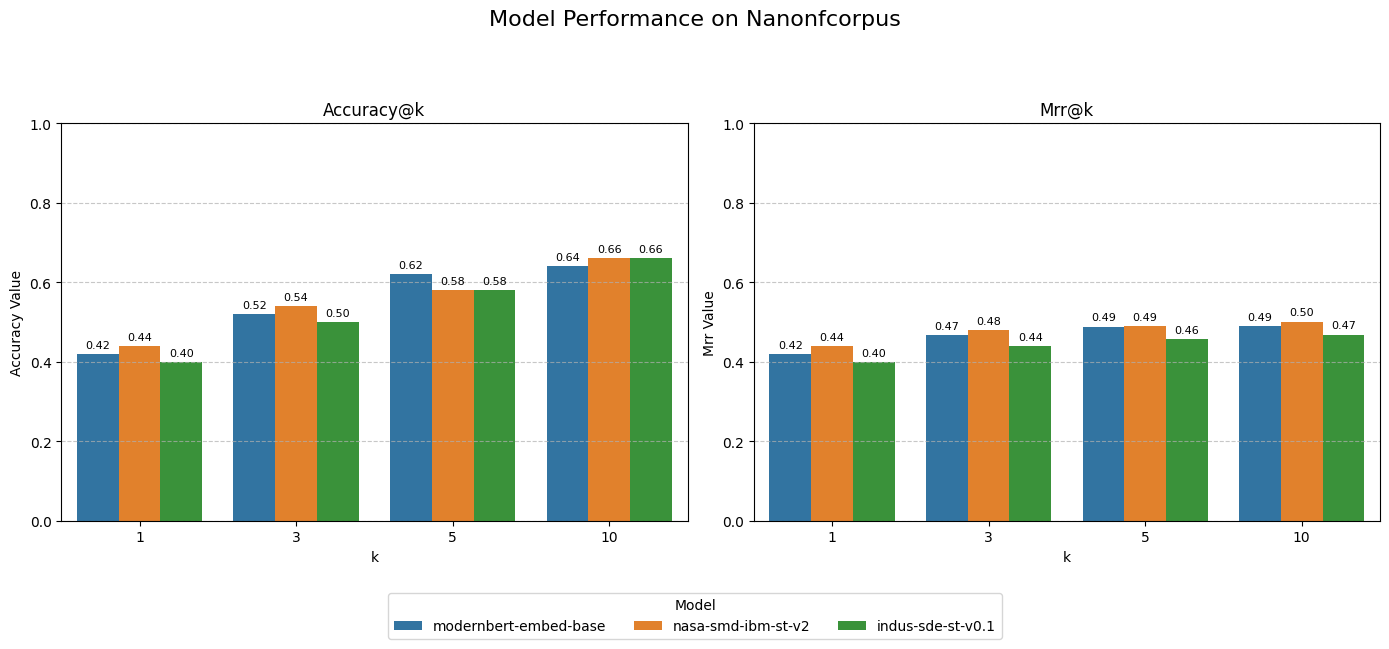

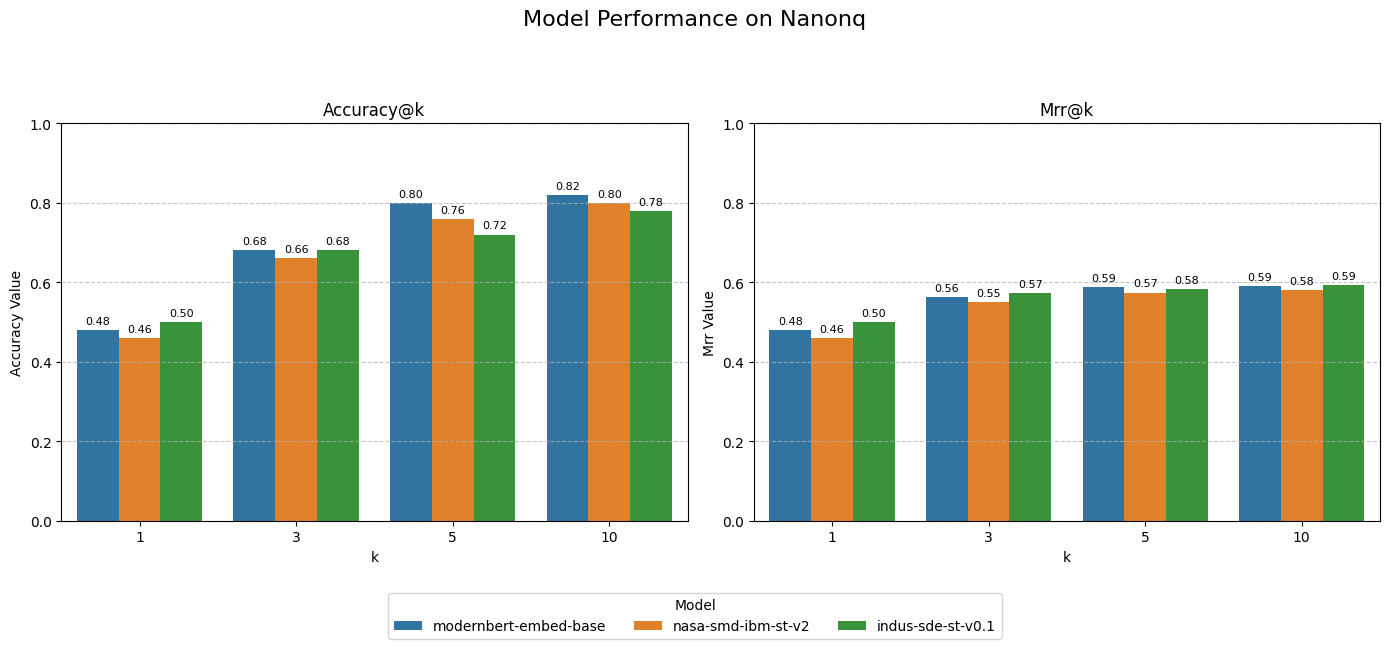

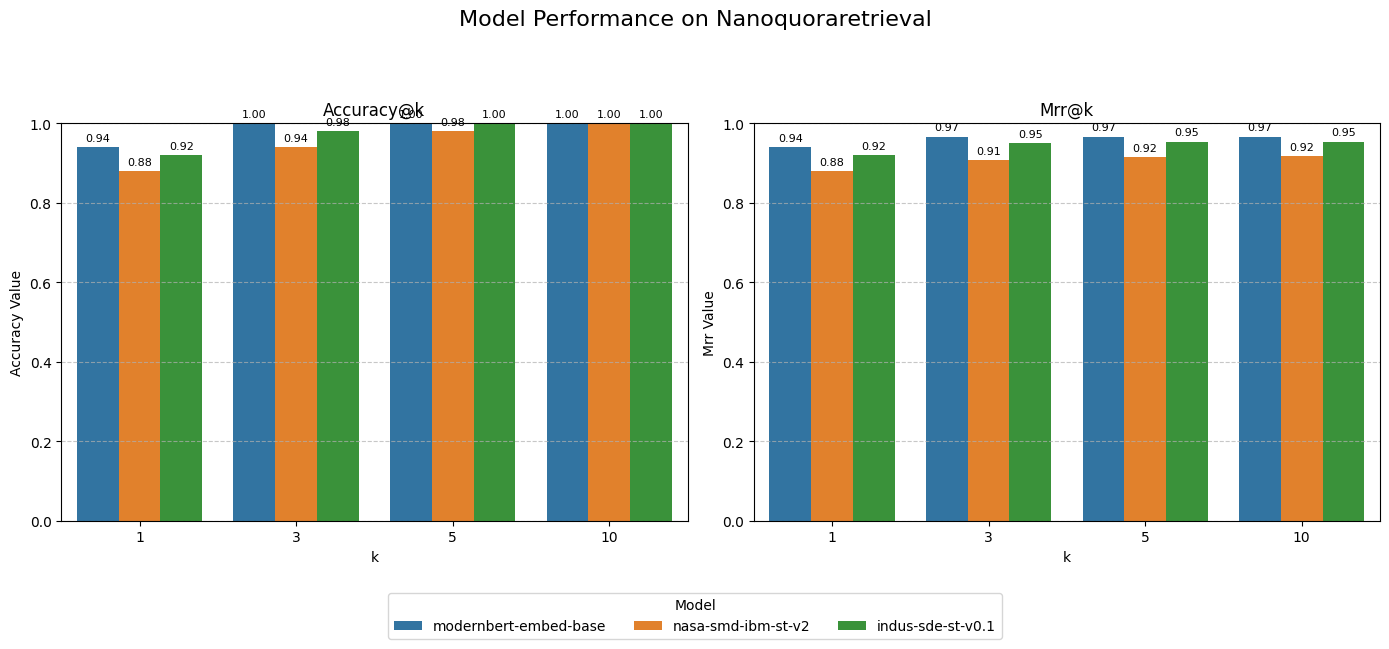

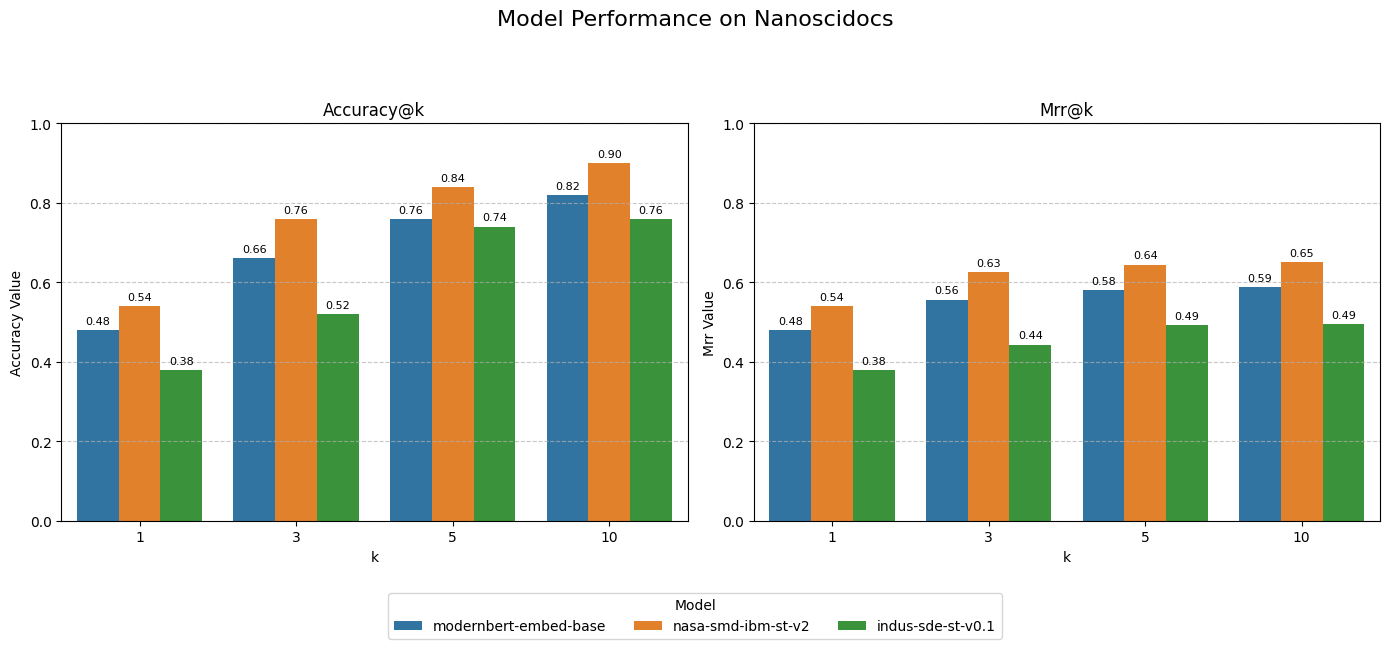

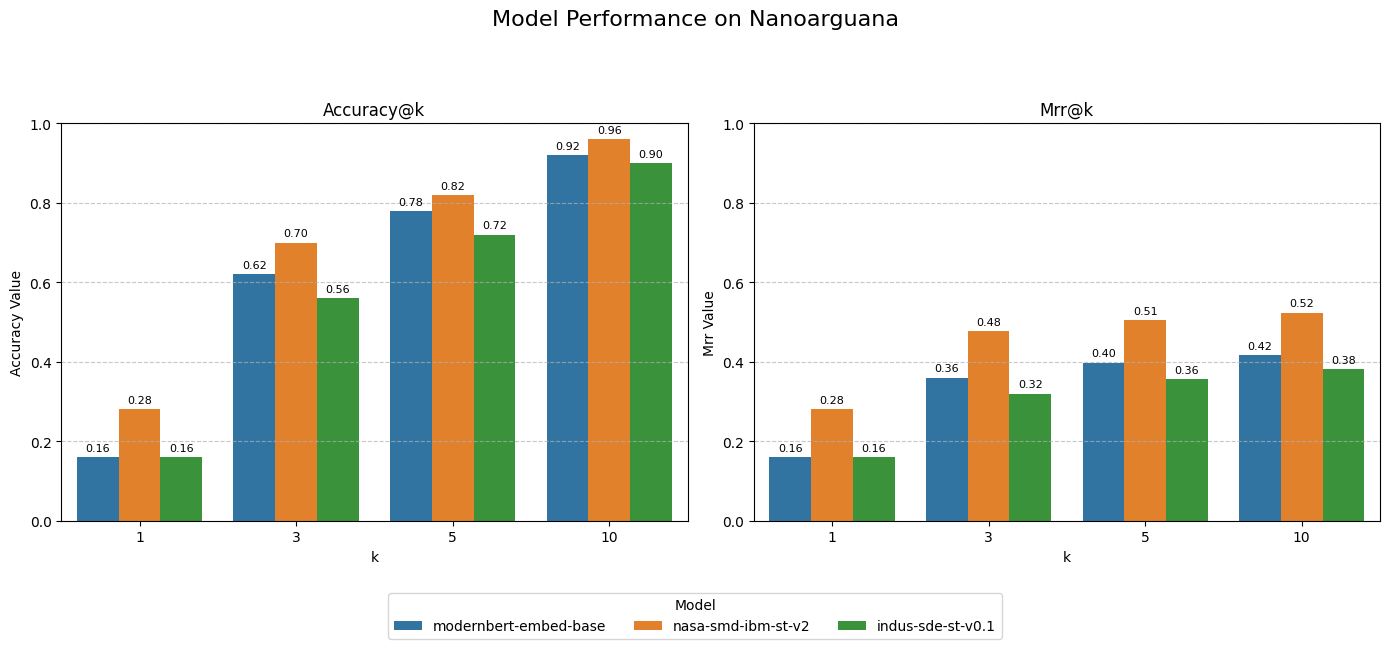

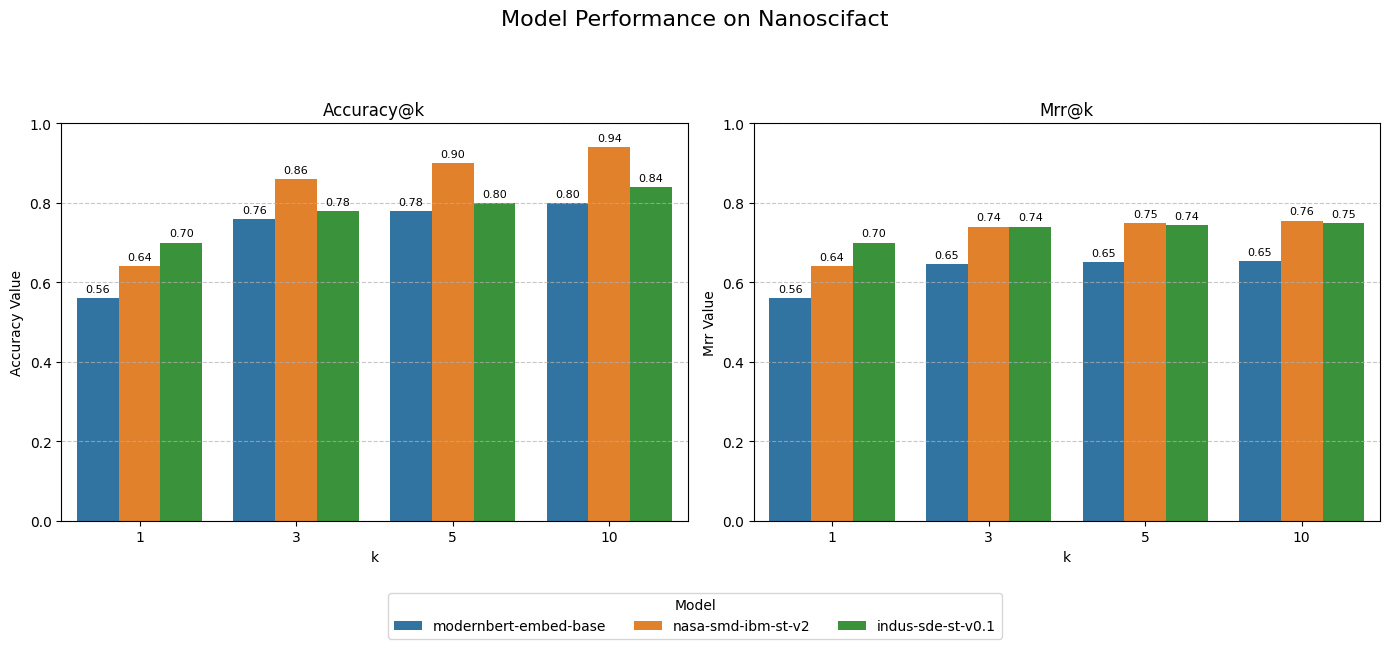

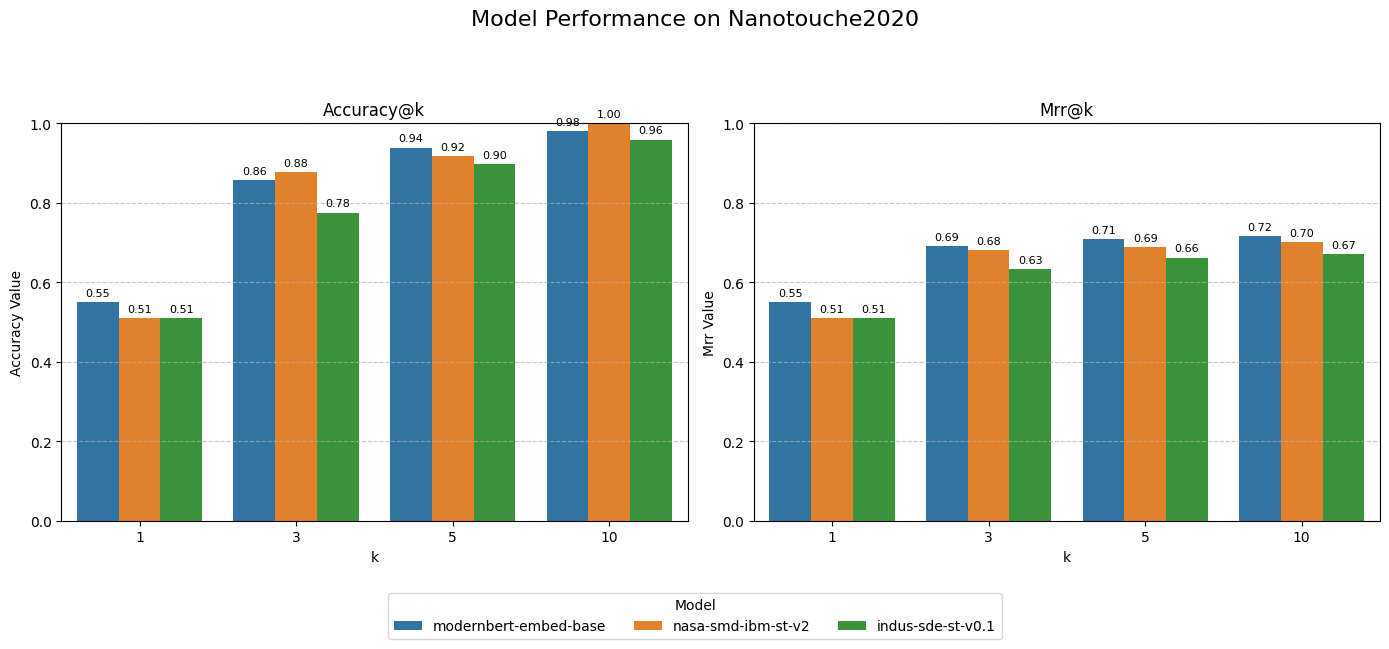

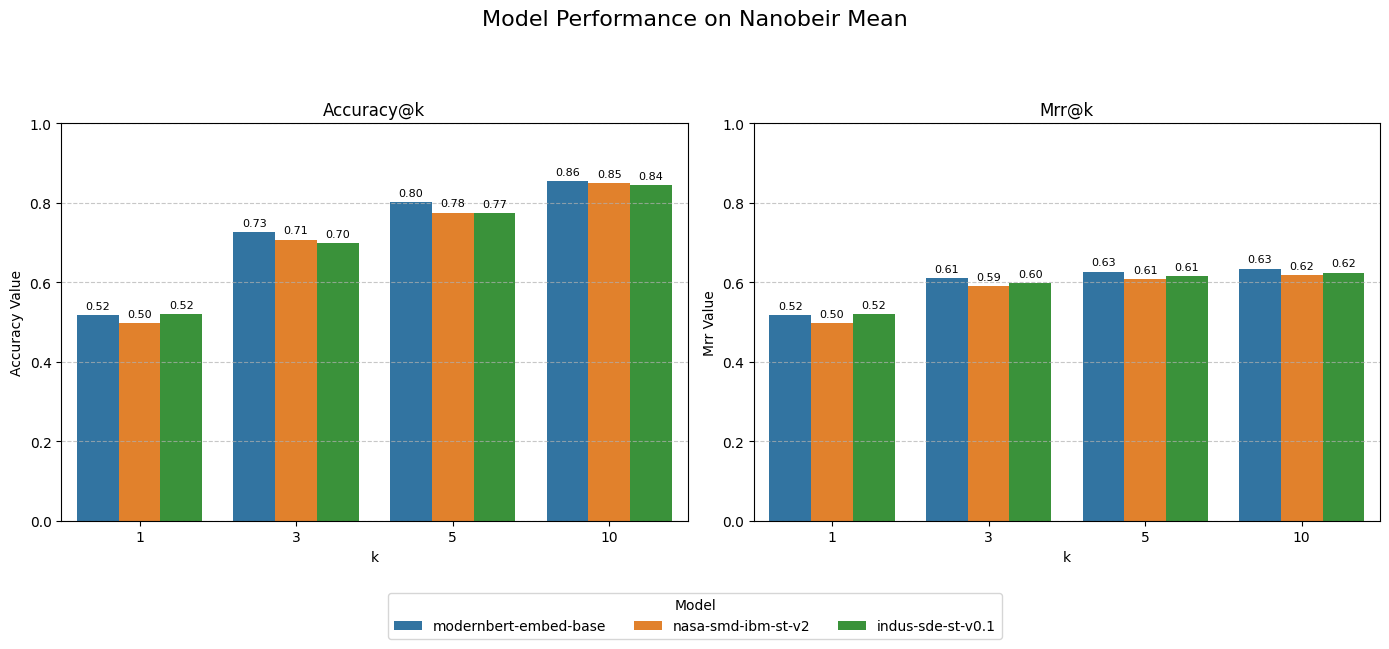


Generating Mean Performance Plot Across All Datasets



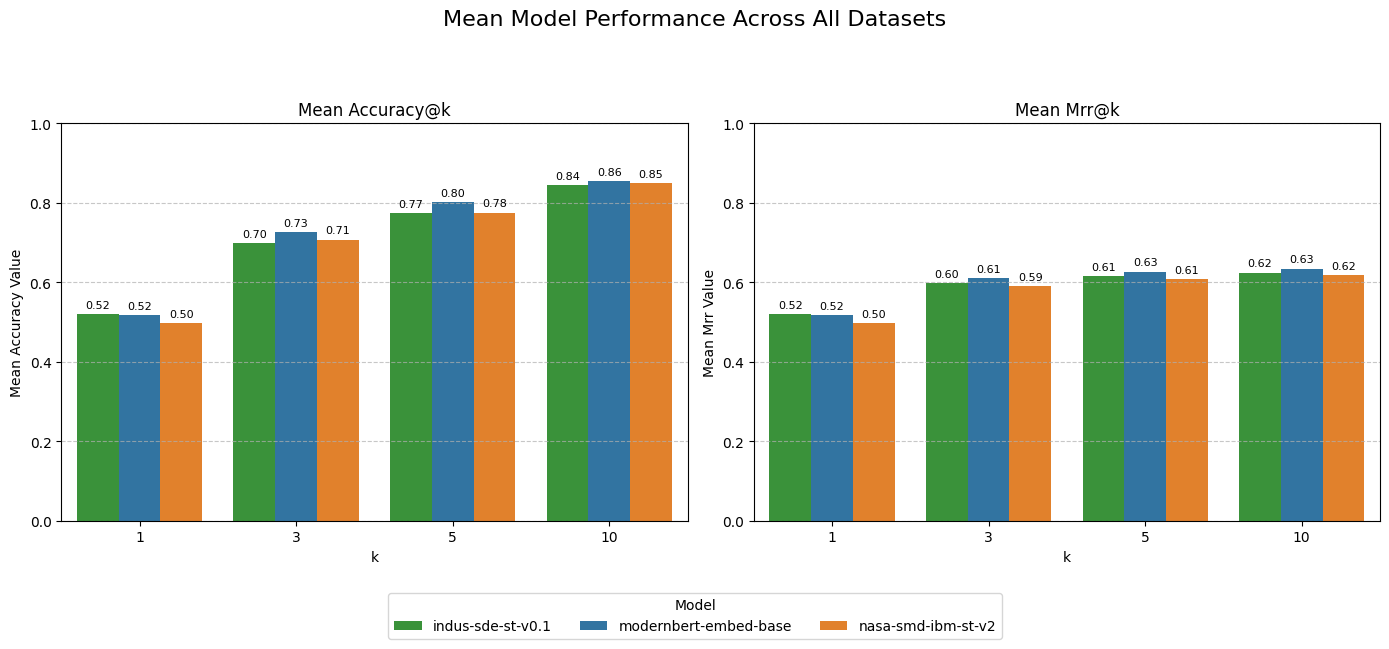

In [10]:
import pandas as pd
import re
from matplotlib import pyplot as plt
import seaborn as sns

# --- Data Transformation ---
# This section converts the nested dictionary into a flat list of records,
# which is then converted into a Pandas DataFrame for easier manipulation.
parsed_data = []
for model_name, metrics_data in data_dump.items():
    for metric_key, value in metrics_data.items():
        try:
            # Use regex to extract dataset, metric type, and k value
            # This makes the parsing more robust to variations in the key format
            match = re.match(r"^(.*?)_cosine_([a-zA-Z]+)@(\d+)$", metric_key)
            if not match:
                print(f"Warning: Unexpected format for key: {metric_key}. Skipping.")
                continue

            dataset_name = match.group(1)
            metric_type = match.group(2)
            k = int(match.group(3)) # Convert k to an integer

            # Append the parsed data as a dictionary to the list
            parsed_data.append({
                'model': model_name,
                'dataset': dataset_name,
                'metric_type': metric_type,
                'k': k,
                'value': value
            })
        except Exception as e:
            # Catch any other parsing errors and report them.
            print(f"Error parsing key '{metric_key}': {e}. Skipping.")

# Convert the list of dictionaries into a Pandas DataFrame
df = pd.DataFrame(parsed_data)

# Convert 'k' to a string type for plotting.
# This ensures that 'k' is treated as a categorical variable on the x-axis,
# preventing Seaborn from trying to interpret it as a continuous number and aggregate.
df['k_str'] = df['k'].astype(str)

# --- Plotting Setup ---
# Get unique identifiers for models, datasets, and metric types present in the data.
# These are now dynamically determined from the parsed DataFrame.
unique_datasets = df['dataset'].unique()
# Filter metric types to only include 'recall' and 'mrr'
desired_metric_types = ['mrr', 'accuracy'] # Changed to MRR and Accuracy
unique_metric_types = [mt for mt in df['metric_type'].unique() if mt in desired_metric_types]

unique_models = df['model'].unique()
unique_k_values = df['k'].unique() # Get all unique k values from the data

# Define a consistent color palette for models.
# This ensures that each model has the same color across all plots for easy comparison.
colors = sns.color_palette("tab10", len(unique_models))
model_color_map = {model: colors[i] for i, model in enumerate(unique_models)}

# --- Generate Plots for Each Dataset ---
# Iterate through each unique dataset to create a separate figure.
for dataset in unique_datasets:
    # Create a figure with subplots. There will be one row and as many columns
    # as there are unique metric types (e.g., MRR and Accuracy).
    # sharey=False is important as their value ranges might differ.
    fig, axes = plt.subplots(1, len(unique_metric_types), figsize=(14, 6), sharey=False)
    
    # Set the main title for the entire figure, indicating the current dataset.
    # Replace underscores for better readability.
    fig.suptitle(f"Model Performance on {dataset.replace('_', ' ').title()}", fontsize=16, y=1.05) # Increased y to make space for bottom legend

    # Ensure 'axes' is always an array, even if there's only one metric type,
    # so that indexing `axes[i]` works consistently.
    if len(unique_metric_types) == 1:
        axes = [axes]

    # Iterate through each metric type (e.g., 'mrr', 'accuracy') to create a subplot.
    for i, metric_type in enumerate(unique_metric_types):
        ax = axes[i] # Get the current subplot axis

        # Filter the DataFrame to get data relevant to the current dataset and metric type.
        plot_data = df[(df['dataset'] == dataset) & (df['metric_type'] == metric_type)].copy()

        # Sort the data by 'k' value to ensure the bars are ordered correctly on the x-axis.
        plot_data = plot_data.sort_values(by='k')

        # Create the bar plot using Seaborn.
        # x='k_str' uses the categorical string representation of k.
        # hue='model' groups bars by model and uses the model_color_map for consistent coloring.
        sns.barplot(
            data=plot_data,
            x='k_str', # Use string for categorical x-axis
            y='value',
            hue='model',
            palette=model_color_map, # Apply consistent color map
            ax=ax
        )

        # Add value labels on top of each bar
        for container in ax.containers:
            ax.bar_label(container, fmt='%.2f', fontsize=8, label_type='edge', padding=3)
        
        # Set subplot title, x-axis label, and y-axis label.
        ax.set_title(f"{metric_type.capitalize()}@k")
        ax.set_xlabel("k")
        ax.set_ylabel(f"{metric_type.capitalize()} Value")
        
        # Set y-axis limits from 0 to 1, as values are typically between this range.
        ax.set_ylim(0, 1.0) 
        
        # Add a grid to the y-axis for easier reading of values.
        ax.grid(axis='y', linestyle='--', alpha=0.7)

        # Remove individual subplot legends as we'll add a single figure-wide legend
        if ax.get_legend():
            ax.get_legend().remove()

    # Adjust the layout to make space for the legend at the bottom.
    plt.tight_layout(rect=[0, 0.1, 1, 0.98]) # Adjusted rect to make space at bottom
    
    # Create a single legend for the entire figure at the bottom
    handles, labels = axes[0].get_legend_handles_labels() # Get handles/labels from the first subplot
    fig.legend(handles, labels, title="Model", loc='lower center', ncol=len(unique_models), bbox_to_anchor=(0.5, 0.0), borderaxespad=0.) # Legend at bottom, one row

    # Display the plot for the current dataset.
    plt.show()

# --- Plotting Mean Performance Across All Datasets ---
print("\n" + "="*50)
print("Generating Mean Performance Plot Across All Datasets")
print("="*50 + "\n")

# Calculate the mean value for each model, metric type, and k value across all datasets.
mean_df = df.groupby(['model', 'metric_type', 'k', 'k_str'], as_index=False)['value'].mean()

# Filter mean_df to include only desired metric types
mean_df = mean_df[mean_df['metric_type'].isin(desired_metric_types)]

# Create a new figure for the mean plots.
fig_mean, axes_mean = plt.subplots(1, len(unique_metric_types), figsize=(14, 6), sharey=False)

# Set the main title for the mean performance figure.
fig_mean.suptitle("Mean Model Performance Across All Datasets", fontsize=16, y=1.05) # Increased y to make space for bottom legend

# Ensure 'axes_mean' is always an array.
if len(unique_metric_types) == 1:
    axes_mean = [axes_mean]

# Iterate through each metric type to create a subplot for mean values.
for i, metric_type in enumerate(unique_metric_types):
    ax_mean = axes_mean[i] # Get the current mean subplot axis

    # Filter data for the current metric type.
    plot_data_mean = mean_df[mean_df['metric_type'] == metric_type].copy()

    # Sort by 'k' to ensure correct order on x-axis.
    plot_data_mean = plot_data_mean.sort_values(by='k')

    # Create the bar plot for mean values.
    sns.barplot(
        data=plot_data_mean,
        x='k_str',
        y='value',
        hue='model',
        palette=model_color_map, # Use the same consistent color map
        ax=ax_mean
    )

    # Add value labels on top of each bar for mean plots
    for container in ax_mean.containers:
        ax_mean.bar_label(container, fmt='%.2f', fontsize=8, label_type='edge', padding=3)

    # Set subplot title, x-axis label, and y-axis label for mean plots.
    ax_mean.set_title(f"Mean {metric_type.capitalize()}@k")
    ax_mean.set_xlabel("k")
    ax_mean.set_ylabel(f"Mean {metric_type.capitalize()} Value")
    ax_mean.set_ylim(0, 1.0)
    ax_mean.grid(axis='y', linestyle='--', alpha=0.7)

    # Remove individual subplot legends.
    if ax_mean.get_legend():
        ax_mean.get_legend().remove()

# Adjust layout and add a single legend for the mean figure.
plt.tight_layout(rect=[0, 0.1, 1, 0.98]) # Adjusted rect to make space at bottom
handles_mean, labels_mean = axes_mean[0].get_legend_handles_labels()
fig_mean.legend(handles_mean, labels_mean, title="Model", loc='lower center', ncol=len(unique_models), bbox_to_anchor=(0.5, 0.0), borderaxespad=0.) # Legend at bottom, one row

# Display the mean performance plot.
plt.show()

In [13]:
# --- Generate and Print Performance Tables ---
# This section creates pivot tables that match the format of the example image.

print("\n" + "="*80)
print("Model Performance Tables")
print("="*80 + "\n")

# Use the metric types you defined earlier
desired_metric_types = ['mrr', 'accuracy'] 
# unique_k_values = sorted(df['k'].unique())

unique_k_values = [5]
# Loop through each metric type (MRR, Accuracy)
for metric_type in desired_metric_types:
    
    # Loop through each k value to create a separate table
    for k_val in unique_k_values:
        
        # --- Create and print the title for the table ---
        title = f"Metric: {metric_type.upper()} @ k={k_val}"
        print(title)
        print("-" * len(title))
        
        # 1. Filter the DataFrame for the current metric and k-value
        filtered_df = df[(df['metric_type'] == metric_type) & (df['k'] == k_val)]
        
        # 2. Pivot the data to get Models as rows and Datasets as columns
        pivot_table = filtered_df.pivot_table(
            index='model', 
            columns='dataset', 
            values='value'
        )
        
        # 3. Calculate the Average score for each model across all datasets
        pivot_table['AVG'] = pivot_table.mean(axis=1)
        
        # 4. Display the final table, formatted to two decimal places
        print(pivot_table.to_string(float_format="%.2f"))
        print("\n" + "="*80 + "\n")


Model Performance Tables

Metric: MRR @ k=5
-----------------
dataset                NanoArguAna  NanoBEIR_mean  NanoClimateFEVER  NanoDBPedia  NanoFEVER  NanoFiQA2018  NanoHotpotQA  NanoMSMARCO  NanoNFCorpus  NanoNQ  NanoQuoraRetrieval  NanoSCIDOCS  NanoSciFact  NanoTouche2020  AVG
model                                                                                                                                                                                                                        
indus-sde-st-v0.1             0.36           0.61              0.37         0.71       0.77          0.50          0.77         0.61          0.46    0.58                0.95         0.49         0.74            0.66 0.61
modernbert-embed-base         0.40           0.63              0.40         0.73       0.78          0.59          0.77         0.50          0.49    0.59                0.97         0.58         0.65            0.71 0.63
nasa-smd-ibm-st-v2            0.51           0.61

In [4]:
import pandas as pd

df = pd.read_parquet(
    "/rhome/sawale/indus_traning/sentense_transformers/gen_data_stage3/filtered_sde_data/", 
    )

df.head()

,id,url1,title,text,n_words,url2,predicted,prob_included
0,/SDE/activate_aerosol_cloud_meteorology_intera...,https://science.larc.nasa.gov/ACTIVATE/data/,ACTIVATE: Data – NASA Langley Research Center...,ACTIVATE: Data - NASA Langley Research Center ...,3975,b'/ACTIVATE/data/',1,0.989475
1,/SDE/activate_aerosol_cloud_meteorology_intera...,https://science.larc.nasa.gov/ACTIVATE/,ACTIVATE: Home – NASA Langley Research Center ...,ACTIVATE: Home - NASA Langley Research Center ...,4659,b'/ACTIVATE/',1,0.990293
2,/SDE/activate_aerosol_cloud_meteorology_intera...,https://science.larc.nasa.gov/ACTIVATE/media/,ACTIVATE: Media – NASA Langley Research Cente...,ACTIVATE: Media - NASA Langley Research Center...,4458,b'/ACTIVATE/media/',1,0.985873
3,/SDE/activate_aerosol_cloud_meteorology_intera...,https://science.larc.nasa.gov/ACTIVATE/instrum...,ACTIVATE: Instruments – NASA Langley Research ...,ACTIVATE: Instruments - NASA Langley Research ...,4126,b'/ACTIVATE/instruments/',1,0.991540
4,/SDE/activate_aerosol_cloud_meteorology_intera...,https://science.larc.nasa.gov/ACTIVATE/education/,ACTIVATE: Education – NASA Langley Research C...,ACTIVATE: Education - NASA Langley Research Ce...,4192,b'/ACTIVATE/education/',1,0.992481


In [ ]:
df[["title", "text"]].head(20)

,title,text
0,ACTIVATE: Data – NASA Langley Research Center...,ACTIVATE: Data - NASA Langley Research Center ...
1,ACTIVATE: Home – NASA Langley Research Center ...,ACTIVATE: Home - NASA Langley Research Center ...
2,ACTIVATE: Media – NASA Langley Research Cente...,ACTIVATE: Media - NASA Langley Research Center...
3,ACTIVATE: Instruments – NASA Langley Research ...,ACTIVATE: Instruments - NASA Langley Research ...
4,ACTIVATE: Education – NASA Langley Research C...,ACTIVATE: Education - NASA Langley Research Ce...
5,2023 ACTIVATE Open Data Workshop – NASA Langle...,2023 ACTIVATE Open Data Workshop - NASA Langle...
6,ACTIVATE: Events – NASA Langley Research Cent...,ACTIVATE: Events - NASA Langley Research Cente...
7,ACTIVATE: Program Participants – NASA Langley...,ACTIVATE: Program Participants - NASA Langley ...
8,ACTIVATE: Science – NASA Langley Research Cen...,ACTIVATE: Science - NASA Langley Research Cent...
9,ACTIVATE: Publications – NASA Langley Researc...,ACTIVATE: Publications - NASA Langley Research...


np.float64(0.0)

In [ ]:
# /rhome/sawale/indus_traning/sentense_transformers/eval/beir_eval_results is folder inside of which has multiple json file for each dataset in beir dataset.add
# the name of json is formated like <dataset_name>.json.


# Inside the json the json format looks like

# {
#     "<model_name>": {
#         "<datasetname>_evaluator_cosine_<metric_name>@<k>": <value>
#     },
#     ...
# }

# I want to create tables comparing different models on different datasets for recall, mrr, accuracy at k=10
    
# the table will look liek this

# Metric: MRR @ k=5
# -----------------
# dataset                NanoArguAna  NanoBEIR_mean  NanoClimateFEVER  NanoDBPedia  NanoFEVER  NanoFiQA2018  NanoHotpotQA  NanoMSMARCO  NanoNFCorpus  NanoNQ  NanoQuoraRetrieval  NanoSCIDOCS  NanoSciFact  NanoTouche2020  AVG
# model                                                                                                                                                                                                                        
# indus-sde-st-v0.1             0.36           0.61              0.37         0.71       0.77          0.50          0.77         0.61          0.46    0.58                0.95         0.49         0.74            0.66 0.61
# modernbert-embed-base         0.40           0.63              0.40         0.73       0.78          0.59          0.77         0.50          0.49    0.59                0.97         0.58         0.65            0.71 0.63
# nasa-smd-ibm-st-v2            0.51           0.61              0.26         0.72       0.68          0.50          0.73         0.43          0.49    0.57                0.92         0.64         0.75            0.69 0.61

# ================================================================================

# Metric: ACCURACY @ k=5
# ----------------------
# dataset                NanoArguAna  NanoBEIR_mean  NanoClimateFEVER  NanoDBPedia  NanoFEVER  NanoFiQA2018  NanoHotpotQA  NanoMSMARCO  NanoNFCorpus  NanoNQ  NanoQuoraRetrieval  NanoSCIDOCS  NanoSciFact  NanoTouche2020  AVG
# model                                                                                                                                                                                                                        
# indus-sde-st-v0.1             0.72           0.77              0.52         0.88       0.96          0.64          0.88         0.72          0.58    0.72                1.00         0.74         0.80            0.90 0.77
# modernbert-embed-base         0.78           0.80              0.56         0.86       0.96          0.80          0.84         0.72          0.62    0.80                1.00         0.76         0.78            0.94 0.80
# nasa-smd-ibm-st-v2            0.82           0.78              0.44         0.88       0.86          0.66          0.84         0.60          0.58    0.76                0.98         0.84         0.90            0.92 0.78


SyntaxError: invalid syntax (4067601101.py, line 1)

In [3]:
import os
import json
import pandas as pd

def create_beir_evaluation_tables(folder_path, k_value=10):
    """
    Processes BEIR evaluation JSON files and creates comparison tables for different metrics.
    Args:
    folder_path (str): The path to the folder containing the JSON files.
    k_value (int): The value of 'k' for the metrics (e.g., 10 for Recall@10).
    """

    metrics_to_extract = ['recall', 'mrr', 'accuracy']
    data = {metric: {} for metric in metrics_to_extract}
    datasets = []

    if not os.path.isdir(folder_path):
        print(f"Error: Directory not found at {folder_path}")
        return

    for filename in sorted(os.listdir(folder_path)):
        if filename.endswith(".json"):
            dataset_name = filename.replace(".json", "")
            datasets.append(dataset_name)
            file_path = os.path.join(folder_path, filename)

            with open(file_path, 'r') as f:
                results = json.load(f)

            for model_name, model_results in results.items():
                for metric_key, value in model_results.items():
                    for metric_name in metrics_to_extract:
                        # Construct the expected metric key suffix
                        expected_suffix = f"_evaluator_cosine_{metric_name}@{k_value}"

                        if metric_key.endswith(expected_suffix):
                            if model_name not in data[metric_name]:
                                data[metric_name][model_name] = {}
                            data[metric_name][model_name][dataset_name] = value

    for metric_name in metrics_to_extract:
        df = pd.DataFrame.from_dict(data[metric_name], orient='index')
        df = df[sorted(df.columns)] # Sort columns alphabetically by dataset name

        # Calculate the average and add it as a new column
        if not df.empty:
            df['AVG'] = df.mean(axis=1)

        # Print the formatted table
        print(f"Metric: {metric_name.upper()} @ k={k_value}")
        print("-" * (len(metric_name) + 8 + len(str(k_value))))
        if not df.empty:
            print(df.to_string(float_format="%.2f"))
        else:
            print(f"No data found for {metric_name} @ k={k_value}")
        print("\n" + "="*80 + "\n")


create_beir_evaluation_tables(folder_path="/rhome/sawale/indus_traning/sentense_transformers/eval/beir_eval_results", k_value=10)




Metric: RECALL @ k=10
----------------
                       arguana  dbpedia-entity  fever  fiqa  hotpotqa  nfcorpus   nq  scidocs  trec-covid  webis-touche2020  AVG
modernbert-embed-base     0.79            0.19   0.81  0.47      0.55      0.14 0.68     0.21        0.02              0.15 0.40
nasa-smd-ibm-st-v2        0.80            0.20   0.71  0.43      0.51      0.16 0.74     0.23        0.02              0.13 0.39
indus-sde-st-v0.1         0.71            0.17   0.75  0.42      0.49      0.15 0.60     0.17        0.02              0.13 0.36


Metric: MRR @ k=10
-------------
                       arguana  dbpedia-entity  fever  fiqa  hotpotqa  nfcorpus   nq  scidocs  trec-covid  webis-touche2020  AVG
modernbert-embed-base     0.25            0.66   0.65  0.46      0.71      0.50 0.42     0.34        0.89              0.42 0.53
nasa-smd-ibm-st-v2        0.27            0.64   0.54  0.43      0.65      0.51 0.50     0.35        0.82              0.31 0.50
indus-sde-st-v0.1      

# generate plot for beir

In [19]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import math
import numpy as np

def generate_beir_comparison_tables(path_to_json_files, output_folder_path, metrics_to_show=None):
    """
    Generates focused Markdown comparison tables from BEIR evaluation results.

    By default, it creates one table per dataset showing specific metrics at k=10.
    The best score for each metric is highlighted in bold.

    Args:
        path_to_json_files (str): Path to the directory with evaluation JSON files.
        output_folder_path (str): Path to the folder to save the table files.
        metrics_to_show (list, optional): A list of strings for the metrics to show
                                          (e.g., ['ndcg@10', 'map@10']). If None, a
                                          default list of metrics at k=10 is used.
    """
    # --- CHANGE: Define the default list of metrics to show ---
    if metrics_to_show is None:
        metrics_to_show = ['accuracy@10', 'mrr@10', 'map@10', 'ndcg@10', 'precision@10', 'recall@10']
        print(f"No metrics specified, using default set: {metrics_to_show}")

    try:
        os.makedirs(output_folder_path, exist_ok=True)
        print(f"Tables will be saved to: {os.path.abspath(output_folder_path)}")
    except OSError as e:
        print(f"Error creating directory {output_folder_path}: {e}")
        return

    try:
        files = [f for f in os.listdir(path_to_json_files) if f.endswith('.json')]
    except FileNotFoundError:
        print(f"Error: The directory '{path_to_json_files}' was not found.")
        return

    for file in files:
        file_path = os.path.join(path_to_json_files, file)
        dataset_name = file.replace('.json', '')

        with open(file_path, 'r') as f:
            data = json.load(f)

        records = []
        for model, metrics_data in data.items():
            for key, value in metrics_data.items():
                try:
                    metric_part = key.split('_cosine_')[-1]
                    metric_name, k = metric_part.split('@')
                    records.append({'model': model, 'metric': metric_name, 'k': int(k), 'value': value})
                except (IndexError, ValueError):
                    print(f"Warning: Could not parse metric key '{key}' in file '{file}'.")

        if not records:
            continue

        df = pd.DataFrame(records)
        df['metric_at_k'] = df['metric'] + '@' + df['k'].astype(str)

        # --- CHANGE: Filter the DataFrame to only include the desired metrics ---
        df_filtered = df[df['metric_at_k'].isin(metrics_to_show)]

        if df_filtered.empty:
            print(f"No data found for the specified metrics in {dataset_name}.")
            continue

        # Pivot the filtered data
        comparison_table = df_filtered.pivot(
            index='model',
            columns='metric_at_k',
            values='value'
        )

        # Ensure the column order matches the desired order
        final_columns = [col for col in metrics_to_show if col in comparison_table.columns]
        comparison_table = comparison_table[final_columns]
        
        # Manually format and bold the max values
        formatted_table = comparison_table.applymap('{:.4f}'.format)
        for col in comparison_table.columns:
            max_val_idx = comparison_table[col].idxmax()
            formatted_table.loc[max_val_idx, col] = f"**{formatted_table.loc[max_val_idx, col]}**"

        # Save the table to a Markdown file
        table_filename = f"{dataset_name}_summary_table.md"
        full_save_path = os.path.join(output_folder_path, table_filename)

        with open(full_save_path, 'w') as f:
            f.write(f"# Summary Results: {dataset_name.upper()}\n\n")
            f.write(formatted_table.to_markdown())

        print(f"✅ Successfully saved summary table to '{full_save_path}'")


def plot_beir_evaluation_results(path_to_json_files, output_folder_path, metrics_to_plot=None):
    """
    Generates subplot images from BEIR evaluation results and saves them.
    (This function is unchanged)
    """
    # ... (The code for the plotting function remains exactly the same as the last version) ...
    try:
        os.makedirs(output_folder_path, exist_ok=True)
        print(f"Plots will be saved to: {os.path.abspath(output_folder_path)}")
    except OSError as e:
        print(f"Error creating directory {output_folder_path}: {e}")
        return

    try:
        files = [f for f in os.listdir(path_to_json_files) if f.endswith('.json')]
    except FileNotFoundError:
        print(f"Error: The directory '{path_to_json_files}' was not found.")
        return

    for file in files:
        file_path = os.path.join(path_to_json_files, file)
        dataset_name = file.replace('.json', '')

        with open(file_path, 'r') as f:
            data = json.load(f)

        records = []
        for model, metrics_data in data.items():
            for key, value in metrics_data.items():
                try:
                    metric_part = key.split('_cosine_')[-1]
                    metric_name, k = metric_part.split('@')
                    records.append({'model': model, 'metric': metric_name, 'k': int(k), 'value': value})
                except (IndexError, ValueError):
                    print(f"Warning: Could not parse metric key '{key}' in file '{file}'.")

        if not records:
            continue

        df = pd.DataFrame(records)

        print("Availab;e metrics in the dataset:", df['metric'].unique())
        
        available_metrics = sorted(df['metric'].unique())
        if metrics_to_plot is None:
            final_metrics_list = available_metrics
        else:
            final_metrics_list = [m for m in metrics_to_plot if m in available_metrics]

        if not final_metrics_list:
            continue
            
        num_metrics = len(final_metrics_list)
        ncols = 2 if num_metrics > 1 else 1
        nrows = math.ceil(num_metrics / ncols)
        
        fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 5 * nrows),
                                 constrained_layout=True)
        
        flat_axes = np.array(axes).flatten()

        fig.suptitle(f'Evaluation for {dataset_name.upper()}', fontsize=20, weight='bold')

        for i, metric in enumerate(final_metrics_list):
            ax = flat_axes[i]
            metric_df = df[df['metric'] == metric]
            
            pivot_df = metric_df.pivot(index='k', columns='model', values='value')

            if pivot_df.empty:
                ax.set_title(f"{metric.upper()}\n(No Data)", fontsize=14)
                continue
                
            pivot_df.plot(kind='bar', ax=ax, width=0.8, legend=False)

            ax.set_title(metric.upper(), fontsize=14)
            ax.set_ylabel(metric.upper(), fontsize=12)
            ax.set_xlabel('Top-k', fontsize=12)
            ax.grid(axis='y', linestyle='--', alpha=0.7)
            ax.tick_params(axis='x', rotation=0)

            for p in ax.patches:
                ax.annotate(f"{p.get_height():.3f}",
                            (p.get_x() + p.get_width() / 2., p.get_height()),
                            ha='center', va='center', fontsize=9,
                            xytext=(0, 9), textcoords='offset points')
        
        for i in range(num_metrics, len(flat_axes)):
            flat_axes[i].axis('off')

        handles, labels = ax.get_legend_handles_labels()
        fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=3, fancybox=True)

        plot_filename = f"{dataset_name}_metrics_summary.png"
        full_save_path = os.path.join(output_folder_path, plot_filename)
        
        plt.savefig(full_save_path, bbox_inches='tight', pad_inches=0.5)
        print(f"✅ Successfully saved consolidated plot to '{full_save_path}'")
        plt.close(fig)


# --- HOW TO USE ---

# 1. Define the path to your JSON files.
results_directory = '/rhome/sawale/indus_traning/sentense_transformers/eval/beir_eval_results'

# 2. Define paths for your outputs.
output_plot_folder = 'beir_evaluation_plots'
output_table_folder = 'beir_evaluation_tables'

# --- Example 1: Generate tables with the default set of metrics (@10) ---
print("--- Generating Default Summary Tables (Metrics @10) ---")
generate_beir_comparison_tables(results_directory, output_table_folder)

# --- Example 2: Generate tables with a custom list of metrics ---
print("\n--- Generating Custom Summary Tables (nDCG@1, nDCG@10, and MAP@10) ---")
custom_metrics_list = ['ndcg@1', 'ndcg@10', 'map@10']
custom_output_folder = 'beir_custom_tables'
generate_beir_comparison_tables(results_directory, custom_output_folder, metrics_to_show=custom_metrics_list)

# --- Example 3: Generate the plots (unchanged) ---
print("\n--- Generating Comparison Plots ---")
plot_beir_evaluation_results(results_directory, output_plot_folder, metrics_to_plot=["mrr", "accuracy"])

--- Generating Default Summary Tables (Metrics @10) ---
No metrics specified, using default set: ['accuracy@10', 'mrr@10', 'map@10', 'ndcg@10', 'precision@10', 'recall@10']
Tables will be saved to: /nas/rhome/sawale/indus_traning/sentense_transformers/eval/beir_evaluation_tables
✅ Successfully saved summary table to 'beir_evaluation_tables/scidocs_summary_table.md'
✅ Successfully saved summary table to 'beir_evaluation_tables/climate-fever_summary_table.md'
✅ Successfully saved summary table to 'beir_evaluation_tables/fever_summary_table.md'
✅ Successfully saved summary table to 'beir_evaluation_tables/quora_summary_table.md'
✅ Successfully saved summary table to 'beir_evaluation_tables/BEIR-average_summary_table.md'
✅ Successfully saved summary table to 'beir_evaluation_tables/nq_summary_table.md'
✅ Successfully saved summary table to 'beir_evaluation_tables/arguana_summary_table.md'
✅ Successfully saved summary table to 'beir_evaluation_tables/hotpotqa_summary_table.md'
✅ Successfull

/tmp/ipykernel_2176491/516474212.py:82: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  formatted_table = comparison_table.applymap('{:.4f}'.format)
/tmp/ipykernel_2176491/516474212.py:82: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  formatted_table = comparison_table.applymap('{:.4f}'.format)
/tmp/ipykernel_2176491/516474212.py:82: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  formatted_table = comparison_table.applymap('{:.4f}'.format)
/tmp/ipykernel_2176491/516474212.py:82: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  formatted_table = comparison_table.applymap('{:.4f}'.format)
/tmp/ipykernel_2176491/516474212.py:82: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  formatted_table = comparison_table.applymap('{:.4f}'.format)
/tmp/ipykernel_2176491/516474212.py:82: FutureWarning: DataFrame.applymap h

✅ Successfully saved consolidated plot to 'beir_evaluation_plots/scidocs_metrics_summary.png'
Availab;e metrics in the dataset: ['accuracy' 'precision' 'recall' 'ndcg' 'mrr' 'map']
✅ Successfully saved consolidated plot to 'beir_evaluation_plots/climate-fever_metrics_summary.png'
Availab;e metrics in the dataset: ['accuracy' 'precision' 'recall' 'ndcg' 'mrr' 'map']
✅ Successfully saved consolidated plot to 'beir_evaluation_plots/fever_metrics_summary.png'
Availab;e metrics in the dataset: ['accuracy' 'precision' 'recall' 'ndcg' 'mrr' 'map']
✅ Successfully saved consolidated plot to 'beir_evaluation_plots/quora_metrics_summary.png'
Availab;e metrics in the dataset: ['accuracy' 'precision' 'recall' 'ndcg' 'mrr' 'map']
✅ Successfully saved consolidated plot to 'beir_evaluation_plots/BEIR-average_metrics_summary.png'
Availab;e metrics in the dataset: ['accuracy' 'precision' 'recall' 'ndcg' 'mrr' 'map']
✅ Successfully saved consolidated plot to 'beir_evaluation_plots/nq_metrics_summary.png'

'/rhome/sawale/indus_traning/sentense_transformers/eval/beir_eval_results'

In [20]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import math
import numpy as np

def generate_cross_dataset_tables(path_to_json_files, output_folder_path, metrics_to_show=None):
    """
    Generates metric-centric Markdown tables comparing models across all datasets.

    Args:
        path_to_json_files (str): Path to the directory with evaluation JSON files.
        output_folder_path (str): Path to the folder to save the table files.
        metrics_to_show (list, optional): A list of metrics to create tables for
                                          (e.g., ['ndcg@10', 'map@10']). Defaults to a
                                          pre-defined list of metrics at k=10.
    """
    if metrics_to_show is None:
        metrics_to_show = ['accuracy@10', 'mrr@10', 'map@10', 'ndcg@10', 'precision@10', 'recall@10']
        print(f"No metrics specified, using default set: {metrics_to_show}")

    try:
        os.makedirs(output_folder_path, exist_ok=True)
        print(f"Cross-dataset tables will be saved to: {os.path.abspath(output_folder_path)}")
    except OSError as e:
        print(f"Error creating directory {output_folder_path}: {e}")
        return

    try:
        files = [f for f in os.listdir(path_to_json_files) if f.endswith('.json')]
    except FileNotFoundError:
        print(f"Error: The directory '{path_to_json_files}' was not found.")
        return

    # 1. Aggregate data from ALL files first
    all_records = []
    for file in files:
        dataset_name = file.replace('.json', '')
        file_path = os.path.join(path_to_json_files, file)
        with open(file_path, 'r') as f:
            data = json.load(f)

        for model, metrics_data in data.items():
            for key, value in metrics_data.items():
                if key.split('_cosine_')[-1] in metrics_to_show:
                    all_records.append({
                        'model': model,
                        'dataset': dataset_name,
                        'metric_at_k': key.split('_cosine_')[-1],
                        'value': value
                    })

    if not all_records:
        print("No data found for any of the specified metrics across all files.")
        return

    df_all = pd.DataFrame(all_records)

    # 2. Create one table for each metric
    for metric_key in metrics_to_show:
        metric_df = df_all[df_all['metric_at_k'] == metric_key]

        if metric_df.empty:
            print(f"--> No data found for metric '{metric_key}'. Skipping table generation.")
            continue

        # Pivot to get models as rows and datasets as columns
        pivoted_table = metric_df.pivot(index='model', columns='dataset', values='value')

        # Format and highlight the best model for each dataset
        formatted_table = pivoted_table.applymap(lambda x: f'{x:.4f}' if pd.notna(x) else 'N/A')
        for col in pivoted_table.columns: # Iterate through datasets
            max_val_idx = pivoted_table[col].idxmax()
            if pd.notna(max_val_idx):
                 formatted_table.loc[max_val_idx, col] = f"**{formatted_table.loc[max_val_idx, col]}**"


        # Save the table to a Markdown file
        table_filename = f"cross_dataset_summary_{metric_key.replace('@', '_at_')}.md"
        full_save_path = os.path.join(output_folder_path, table_filename)

        with open(full_save_path, 'w') as f:
            f.write(f"# Cross-Dataset Comparison: {metric_key.upper()}\n\n")
            f.write(formatted_table.to_markdown())

        print(f"✅ Successfully saved cross-dataset table for '{metric_key}' to '{full_save_path}'")


# Note: The previous functions 'generate_beir_comparison_tables' and
# 'plot_beir_evaluation_results' are omitted here for brevity but
# would still work as before. You can add them back to this script if needed.


# --- HOW TO USE THE NEW FUNCTION ---

# 1. Define the path to your JSON files.
results_directory = '/rhome/sawale/indus_traning/sentense_transformers/eval/beir_eval_results'

# 2. Define a path for your new cross-dataset tables.
cross_dataset_table_folder = 'beir_cross_dataset_tables'

# 3. Run the new function.
print("--- Generating Cross-Dataset Summary Tables ---")
generate_cross_dataset_tables(results_directory, cross_dataset_table_folder)

# Example of using a custom list of metrics
print("\n--- Generating Custom Cross-Dataset Tables ---")
custom_metrics = ['ndcg@1', 'recall@100']
generate_cross_dataset_tables(results_directory, cross_dataset_table_folder, metrics_to_show=custom_metrics)

--- Generating Cross-Dataset Summary Tables ---
No metrics specified, using default set: ['accuracy@10', 'mrr@10', 'map@10', 'ndcg@10', 'precision@10', 'recall@10']
Cross-dataset tables will be saved to: /nas/rhome/sawale/indus_traning/sentense_transformers/eval/beir_cross_dataset_tables
✅ Successfully saved cross-dataset table for 'accuracy@10' to 'beir_cross_dataset_tables/cross_dataset_summary_accuracy_at_10.md'
✅ Successfully saved cross-dataset table for 'mrr@10' to 'beir_cross_dataset_tables/cross_dataset_summary_mrr_at_10.md'
✅ Successfully saved cross-dataset table for 'map@10' to 'beir_cross_dataset_tables/cross_dataset_summary_map_at_10.md'
✅ Successfully saved cross-dataset table for 'ndcg@10' to 'beir_cross_dataset_tables/cross_dataset_summary_ndcg_at_10.md'
✅ Successfully saved cross-dataset table for 'precision@10' to 'beir_cross_dataset_tables/cross_dataset_summary_precision_at_10.md'
✅ Successfully saved cross-dataset table for 'recall@10' to 'beir_cross_dataset_tables/

/tmp/ipykernel_2176491/3599725504.py:72: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  formatted_table = pivoted_table.applymap(lambda x: f'{x:.4f}' if pd.notna(x) else 'N/A')
/tmp/ipykernel_2176491/3599725504.py:72: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  formatted_table = pivoted_table.applymap(lambda x: f'{x:.4f}' if pd.notna(x) else 'N/A')
/tmp/ipykernel_2176491/3599725504.py:72: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  formatted_table = pivoted_table.applymap(lambda x: f'{x:.4f}' if pd.notna(x) else 'N/A')
/tmp/ipykernel_2176491/3599725504.py:72: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  formatted_table = pivoted_table.applymap(lambda x: f'{x:.4f}' if pd.notna(x) else 'N/A')
/tmp/ipykernel_2176491/3599725504.py:72: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  formatted_table = p

In [16]:
# generate average 
import json

average_dict = {}
path_to_json_files = "/rhome/sawale/indus_traning/sentense_transformers/eval/beir_eval_results"
files = [f for f in os.listdir(path_to_json_files) if f.endswith('.json')]

for fp in files:
    file_path = os.path.join(path_to_json_files, fp)
    # get json
    with open(file_path, 'r') as f:
        data = json.load(f)
    for model, metrics_data in data.items():
        if average_dict.get(model) is None:
            average_dict[model] = {}
        for key, value in metrics_data.items():
            # parse_the key
            parts = key.split('_cosine_')
            new_key = "BEIR-average_evaluator_cosine_" + parts[1]
            if average_dict[model].get(new_key) is None:
                # create a new list for this key
                average_dict[model][new_key] = []
            average_dict[model][new_key].append(value)

# now taking the average

for model, metrics in average_dict.items():
    for key, values in metrics.items():
        average_value = sum(values) / len(values)
        average_dict[model][key] = average_value

average_dict

{'modernbert-embed-base': {'BEIR-average_evaluator_cosine_accuracy@1': 0.46725717738814065,
  'BEIR-average_evaluator_cosine_accuracy@3': 0.6506235259044656,
  'BEIR-average_evaluator_cosine_accuracy@5': 0.718518737333549,
  'BEIR-average_evaluator_cosine_accuracy@10': 0.7907275377895727,
  'BEIR-average_evaluator_cosine_precision@1': 0.46725717738814065,
  'BEIR-average_evaluator_cosine_precision@3': 0.3298406193166798,
  'BEIR-average_evaluator_cosine_precision@5': 0.2748944743311695,
  'BEIR-average_evaluator_cosine_precision@10': 0.2122506771069062,
  'BEIR-average_evaluator_cosine_recall@1': 0.19891373645024446,
  'BEIR-average_evaluator_cosine_recall@3': 0.3239903624461732,
  'BEIR-average_evaluator_cosine_recall@5': 0.37834045441933967,
  'BEIR-average_evaluator_cosine_recall@10': 0.44728976687470146,
  'BEIR-average_evaluator_cosine_ndcg@1': 0.46725717738814065,
  'BEIR-average_evaluator_cosine_ndcg@3': 0.4725397774321328,
  'BEIR-average_evaluator_cosine_ndcg@5': 0.47977338343

In [18]:
# save the average_dict to a json file
path_to_save = "/rhome/sawale/indus_traning/sentense_transformers/eval/beir_eval_results/BEIR-average.json"
with open(path_to_save, 'w') as f:
    json.dump(average_dict, f, indent=4)

